# Explore linear unmixing on raw data

## Overview

This notebook explores **spectral linear unmixing** of HCR fluorescence image data.  
Because each fluorophore bleeds signal into neighboring detection channels, raw intensities are a linear mixture of the true sources. Unmixing recovers the per-fluorophore signal by inverting the mixing matrix **A**.

---

### What we do

| Step | Cell(s) | Description |
|------|---------|-------------|
| 1 | Load data | Attach the mouse catalog record, build the dataset, load a single-cell 3-D zarr crop for every channel |
| 2 | Mixing matrix | Load or estimate **A** (see section below) |
| 3 | Visualize **A** | Heatmap — diagonal = 1 (self-signal), off-diagonal = fractional bleed-through |
| 4 | Unmix | Invert the system **A s = y** per voxel to recover the source signals **s** |
| 5 | Compare | Side-by-side raw vs. unmixed images |

---

### Sources for the mixing matrix A

**A** encodes how much signal from fluorophore *j* bleeds into detector channel *i* (diagonal = 1, off-diagonal = fraction). There are three ways to obtain it, with different trade-offs:

#### 1. Load from pipeline ratios file — `load_mixing_matrix_from_txt` ✓ used here
- Reads the `*_ratios.txt` written by the spot-detection pipeline for a given round
- Ratios are computed from **spot-level data**: for each pairwise channel combination, the pipeline finds co-localised spots and measures the intensity ratio in each detector
- **Pros:** derived from real signal (not background), stable across many cells, matches the same round/acquisition conditions exactly
- **Cons:** requires a successfully processed asset; the ratio file must exist and the channel order must match
- Values are on a 0–100 scale (diagonal = 100); divided by 100 before use

#### 2. Load from pairwise unmixing derived asset — `load_mixing_matrix_from_dataset`
- Reads the ratios CSV from a `pairwise_unmixing` derived asset attached to the mouse record
- Produced by a separate pairwise-unmixing pipeline run rather than the main spot pipeline
- **Pros:** same spot-based approach, may be available when the main pipeline ratios file is not; useful for comparing pipeline versions
- **Cons:** requires the `pairwise_unmixing` derived asset to be present in the catalog record; CSV index handling needs care (first column consumed as index by `read_csv`)

#### 3. Estimate from pure voxels in the image — `estimate_mixing_matrix_pure_voxels`
- Identifies voxels where one channel is very bright **and** dominant over all others by a threshold ratio
- The mean spectral vector at those pure voxels becomes the column of **A** for that fluorophore
- **Pros:** no pre-computed asset needed; can be computed on-the-fly for any crop; adapts to local imaging conditions
- **Cons:** requires sufficient bright, well-separated signal in the crop; sensitive to `top_pct` and `dominance_ratio` hyperparameters; noisy for small crops or dim probes; column estimates can be unstable if channels are highly correlated

#### Choosing which to use

| Situation | Recommended source |
|---|---|
| Pipeline has run successfully, ratios file present | `load_mixing_matrix_from_txt` (most reproducible) |
| Pairwise unmixing asset exists but no ratios txt | `load_mixing_matrix_from_dataset` |
| No pre-computed asset; exploratory / QC work | `estimate_mixing_matrix_pure_voxels` |
| Sanity-check or comparison between methods | Run all three and compare heatmaps side-by-side |

---

### Unmixing solver methods compared

The core problem is: given observed intensity vector **y** (C channels) and mixing matrix **A** (C×C), find source vector **s ≥ 0** such that **A s ≈ y**.

#### `scipy.optimize.nnls` — true NNLS (original, slow)
- Runs the Lawson–Hanson active-set algorithm for **each voxel** in a Python loop
- Strictly enforces **s ≥ 0** — any channel that is pure bleed-through is driven exactly to zero
- **Bottleneck:** Python loop overhead × N_voxels; ~1–5 min for a single cell crop

#### `np.linalg.solve` + clip — fast vectorized (current)
- Calls a single LAPACK routine over **all voxels at once**: `S = np.linalg.solve(A, Y)`, then `S = np.maximum(0, S)`
- **~100–1000× faster** than the loop; no new dependencies
- Clip-vs-NNLS difference: only matters when a channel truly contributes zero signal (rare in HCR, where every probe has some on-target signal in the volume)

---

### Scaling to thousands of cells

Because **A is fixed for the whole imaging round**, all cells can be concatenated into a single `(C, N_total)` matrix and solved in one call.

| Scenario | Function | Notes |
|---|---|---|
| Single cell, interactive | `apply_unmixing_fast` | Single LAPACK call over ~10 k–100 k voxels |
| 100s–1000s of cells, CPU | `apply_unmixing_batch` | Concat all → one solve; ~800 MB per 1 000 cells at float64 |
| Large scale, GPU available | `apply_unmixing_batch(..., use_gpu=True)` | CuPy mirrors NumPy API; `pip install cupy-cuda12x` |
| Memory-constrained | `apply_unmixing_batch(..., batch_size=500)` | Splits into sub-batches; caps peak RAM/VRAM |


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
import aind_hcr_qc.viz.single_cell_unmixing as scu
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.spot_detection import annotate_spots_df, plot_removal_metric_distributions
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT


In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "782149"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/single_cell_unmixing/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pairwise_asset_path = DATA_DIR / pairwise_asset_name
    # Some pipeline outputs nest data under a "pairwise_unmixing" subfolder
    if (pairwise_asset_path / "pairwise_unmixing").exists():
        pairwise_asset_path = pairwise_asset_path / "pairwise_unmixing"
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=pairwise_asset_path,
        source_dataset=dataset,   # delegates zarr / segmentation calls
        min_dist=1
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")


  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-04-15_21-20-31  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixe

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 561, 594, 405, 488
  R2: 638, 514, 488, 594, 561, 405
  R3: 514, 638, 488, 561, 594, 405
  R4: 514, 594, 488, 405, 638, 561
  R5: 561, 405, 514, 594, 488, 638

Cell-typing: ✓  (CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✗

Spot detection files by round:
  R1: channels 594, 488, 561
    594: spots ✓, stats files: 3
    488: spots ✓, stats files: 3
    561: spots ✓, stats files: 3
  R2: channels 561, 594, 638, 488, 514
    561: spots ✓, stats files: 5
    594: spot

In [5]:
cids = [70728,
 64094,
 80164,
 71414,
 68992,
 71600,
 74695,
 74644,
 71684,
 18878,
 80227,
 63960,
 69052,
 63765,
 81912,
 81847,
 81762,
 81024,
 74373,
 74296,
 69532,
 80302,
 71351,
 74104,
 57140]

In [6]:
import aind_hcr_qc.io.zarr_data as zarr_data


def load_cell_zarr_chunks_all_channels(
    dataset,
    round_key: str,
    cell_id: int,
    pyramid_level: str = "0",
    data_type: str = "fused",
    num_planes: int = 5,
    plot_buffer: int = 50,
):
    """Load 3-D zarr crops for every channel of a given round around a single cell.

    Parameters
    ----------
    dataset : HCRDataset
    round_key : str
        e.g. "R1"
    cell_id : int
    pyramid_level : str
        Zarr pyramid level (default "0" = full resolution)
    data_type : str
        "fused" | "corrected" | "raw"
    num_planes, plot_buffer : int
        Passed through to extract_cell_volume.

    Returns
    -------
    channel_crops : dict[str, np.ndarray]
        {channel: 3-D array (z, y, x)}
    origin : tuple[int, int, int]
        (zmin, ymin, xmin) global voxel origin of the crop
    extras : dict
        seg_crop, img_crop, masks_only, cell_mask_only, z_planes, x_planes
    """
    # ── cell info ─────────────────────────────────────────────────────────────
    cell_info_df = dataset.rounds[round_key].get_cell_info(source="mixed_cxg")
    cell_info_array = cell_info_df[["z_centroid", "y_centroid", "x_centroid", "cell_id"]].to_numpy()

    # ── reference channel (405 or first available) ────────────────────────────
    channels = dataset.rounds[round_key].get_channels(data_type=data_type)
    ref_channel = "405" if "405" in channels else sorted(channels)[0]

    segmentation_zarr = dataset.load_segmentation_mask(round_key, pyramid_level)
    ref_zarr = dataset.load_zarr_channel(round_key, ref_channel, data_type=data_type, pyramid_level=pyramid_level)

    # ── bounding box ──────────────────────────────────────────────────────────
    seg_crop, img_crop, masks_only, cell_mask_only, origin, z_planes, x_planes = zarr_data.extract_cell_volume(
        segmentation_zarr, ref_zarr, cell_info_array, cell_id,
        num_planes=num_planes, plot_buffer=plot_buffer,
    )

    z0, y0, x0 = origin
    z1, y1, x1 = z0 + seg_crop.shape[0], y0 + seg_crop.shape[1], x0 + seg_crop.shape[2]

    # ── load every channel ────────────────────────────────────────────────────
    channel_crops = {}
    for chan in sorted(channels):
        chan_zarr = dataset.load_zarr_channel(round_key, chan, data_type=data_type, pyramid_level=pyramid_level)
        channel_crops[chan] = np.asarray(chan_zarr[0, 0, z0:z1, y0:y1, x0:x1])

    extras = dict(
        seg_crop=seg_crop, img_crop=img_crop,
        masks_only=masks_only, cell_mask_only=cell_mask_only,
        z_planes=z_planes, x_planes=x_planes,
    )
    return channel_crops, origin, extras


In [7]:
def plot_cell_channel_crops(
    channel_crops: dict,
    extras: dict,
    cmap_dict: dict = None,
    z_plane: int = None,
    percentile_range: tuple = (2, 98),
    vmin_vmax: "str | tuple | dict" = "auto",
    ncols: int = None,
    figsize_per_panel: tuple = (2.5, 2.5),
):
    """
    Quick-look plot of all channel crops for a single cell.

    Parameters
    ----------
    channel_crops : dict[str, np.ndarray]
        Output of load_cell_zarr_chunks_all_channels — {channel: (z, y, x) array}.
    extras : dict
        The 'extras' dict from the same function (used for seg overlay).
    cmap_dict : dict, optional
        {channel: hex/color} mapping.  Falls back to Z1_CHANNEL_CMAP_VIBRANT.
    z_plane : int, optional
        Which z slice to show.  Defaults to the middle plane of the cell.
    percentile_range : tuple
        (lo, hi) percentiles used when vmin_vmax="auto".
    vmin_vmax : "auto" | (vmin, vmax) | dict[str, (vmin, vmax)]
        "auto"          — per-channel percentile stretch (default).
        (vmin, vmax)    — fixed range applied to every channel.
        dict            — per-channel fixed range, e.g. {"488": (0, 500)}.
                          Channels not in the dict fall back to "auto".
    ncols : int, optional
        Number of columns.  Defaults to number of channels.
    figsize_per_panel : tuple
        (w, h) per subplot panel in inches.
    """
    if cmap_dict is None:
        cmap_dict = Z1_CHANNEL_CMAP_VIBRANT

    channels = sorted(channel_crops.keys())
    n = len(channels)
    if ncols is None:
        ncols = n
    nrows = int(np.ceil(n / ncols))

    # choose z plane
    if z_plane is None:
        z_planes = extras.get("z_planes")
        z_plane = int(z_planes[len(z_planes) // 2]) if z_planes is not None else channel_crops[channels[0]].shape[0] // 2

    # cell mask outline for overlay
    cell_mask_only = extras.get("cell_mask_only")  # (z, y, x) bool/uint

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    for idx, chan in enumerate(channels):
        ax = axes[idx // ncols][idx % ncols]
        vol = channel_crops[chan]
        slc = vol[z_plane]

        # resolve vmin/vmax
        if isinstance(vmin_vmax, dict):
            rng = vmin_vmax.get(chan, "auto")
        else:
            rng = vmin_vmax

        if rng == "auto":
            vmin, vmax = np.percentile(slc, percentile_range)
        else:
            vmin, vmax = rng

        ax.imshow(slc, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")

        # overlay cell outline in channel colour
        if cell_mask_only is not None:
            outline = cell_mask_only[z_plane].astype(float)
            color = cmap_dict.get(chan, "#ffffff")
            r, g, b, _ = to_rgba(color)
            rgba = np.zeros((*outline.shape, 4))
            rgba[..., 0] = r
            rgba[..., 1] = g
            rgba[..., 2] = b
            rgba[..., 3] = outline * 0.8
            ax.imshow(rgba, interpolation="nearest")

        ax.set_title(f"ch {chan}\n[{vmin:.0f}, {vmax:.0f}]", color=cmap_dict.get(chan, "white"), fontsize=8)
        ax.axis("off")

    # hide unused axes
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")

    fig.suptitle(f"z = {z_plane}", fontsize=10, y=1.01)
    plt.tight_layout()
    return fig





In [8]:
channel_crops, origin, extras = load_cell_zarr_chunks_all_channels(
    dataset, round_key="R5", cell_id=32882
)


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R5


/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


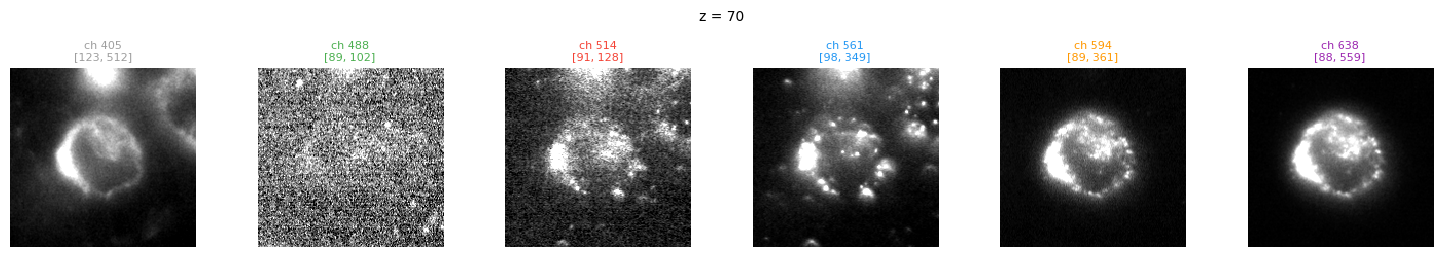

In [9]:
# ── example call ──────────────────────────────────────────────────────────────
fig = plot_cell_channel_crops(channel_crops, extras)
plt.show()

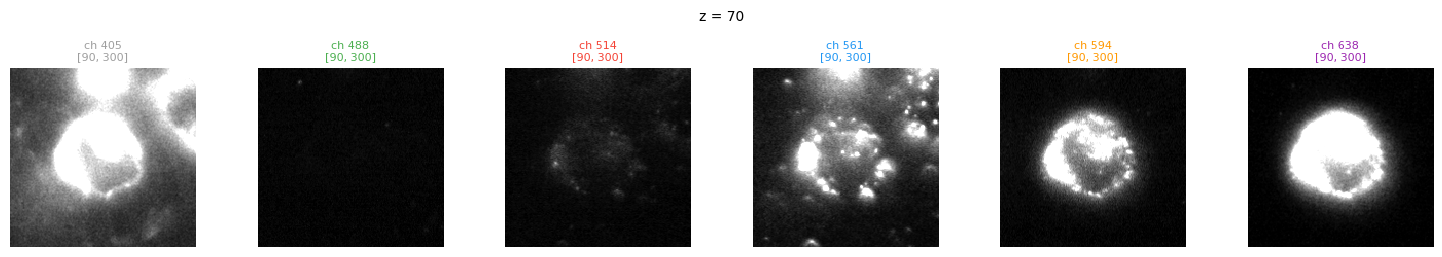

In [10]:
fig = plot_cell_channel_crops(channel_crops, extras,vmin_vmax=(90, 300))
plt.show()

In [11]:
from aind_hcr_qc.viz.spectral_unmixing import read_ratios_file


def load_mixing_matrix_from_dataset(pw_ds, round_key: str, exclude_structural: str = "405") -> tuple:
    """Load the pre-calculated spectral mixing matrix from the pairwise unmixing asset.

    NOTE on CSV format:  load_ratios_matrix() uses pd.read_csv(..., index_col=0),
    so the first data column becomes the DataFrame index — leaving an apparent
    (n_ch, n_ch-1) shape.  We recover the full (n_ch × n_ch) matrix by
    prepending the index back as the first column (same fix used in
    compute_dye_line_distances_numpy).

    Values in the file are on a 0–100 scale (diagonal=100); we divide by 100
    so the diagonal = 1 and off-diagonals are fractional bleed-through.

    Parameters
    ----------
    pw_ds : PairwiseUnmixingDataset
    round_key : str  e.g. "R2"
    exclude_structural : str
        Channel label to drop.  Default "405".

    Returns
    -------
    A : np.ndarray, shape (C, C)
        Mixing matrix, column j = spectral signature of fluorophore j, diagonal = 1.
    channels : list[str]
        Ordered channel names corresponding to rows/columns of A.
    """
    ratios_df = pw_ds.rounds[round_key].load_ratios_matrix()
    ratios_df.index   = ratios_df.index.astype(str)
    ratios_df.columns = ratios_df.columns.astype(str)

    # Recover the full square matrix (first column was consumed as index by read_csv)
    first_col = np.array(ratios_df.index.values, dtype=np.float32).reshape(-1, 1)
    full_matrix = np.hstack([first_col, ratios_df.values.astype(np.float32)])

    # Build a properly labelled DataFrame over all channels
    all_channels = sorted(ratios_df.index.tolist())
    full_df = pd.DataFrame(full_matrix, index=all_channels, columns=all_channels)

    # Drop structural channel
    channels = [c for c in all_channels if c != exclude_structural]
    full_df = full_df.loc[channels, channels]

    # Normalise 0-100 → 0-1
    A = full_df.values / 100.0
    return A, channels


def load_mixing_matrix_from_txt(dataset, round_key: str,
                                exclude_structural: str = "405",
                                chan_order: list = None) -> tuple:
    """Load the mixing matrix from the processed asset's *_ratios.txt file.

    Parameters
    ----------
    dataset : HCRDataset
    round_key : str  e.g. "R2"
    exclude_structural : str
        Channel label to drop.
    chan_order : list[str], optional
        Explicit channel ordering matching the rows/columns of the txt file.
        If None, infers from the round's sorted gene-expression channels.

    Returns
    -------
    A : np.ndarray, shape (C, C)
        Mixing matrix, diagonal = 1, off-diagonals = fractional bleed-through.
    channels : list[str]
        Ordered channel names corresponding to rows/columns of A.
    """
    ratios_path = dataset.rounds[round_key].spot_files.ratios_file
    if ratios_path is None or not ratios_path.exists():
        raise FileNotFoundError(f"No ratios file for {round_key}: {ratios_path}")

    raw = read_ratios_file(ratios_path)  # (C, C) numpy array, 0-100 scale

    if chan_order is None:
        all_chans = sorted(dataset.rounds[round_key].get_channels(data_type="fused"))
        chan_order = [c for c in all_chans if c != exclude_structural]

    assert raw.shape[0] == len(chan_order), (
        f"Matrix shape {raw.shape} does not match {len(chan_order)} channels: {chan_order}"
    )

    A = raw / 100.0  # normalise so diagonal = 1
    return A.T, chan_order


# ── example: load from the processed asset .txt file ─────────────────────────
ROUND_KEY = "R2"
A_txt, expr_channels_txt = load_mixing_matrix_from_txt(dataset, ROUND_KEY)
print(f"Loaded from .txt  shape={A_txt.shape}  channels={expr_channels_txt}")
print(pd.DataFrame(A_txt, index=expr_channels_txt, columns=expr_channels_txt).round(3))


Loaded from .txt  shape=(5, 5)  channels=['488', '514', '561', '594', '638']
      488   514   561   594   638
488  1.00  0.20  0.03  0.05  0.04
514  0.21  0.99  0.13  0.05  0.04
561  0.05  0.13  1.00  0.39  0.11
594  0.07  0.11  0.07  1.00  0.56
638  0.01  0.04  0.03  0.06  1.00


In [12]:
from scipy.optimize import nnls


# ── Step 1: estimate mixing matrix via pure-voxel spectral signatures ─────────

def estimate_mixing_matrix_pure_voxels(
    channel_crops: dict,
    top_pct: float = 99.0,
    dominance_ratio: float = 3.0,
    exclude_structural: str = "405",
    verbose: bool = True,
) -> tuple:
    """Estimate a spectral mixing matrix from the image data using pure voxels.

    For each fluorophore channel, "pure" voxels are those where that channel
    is very bright AND is dominant over every other channel by at least
    `dominance_ratio`.  The mean full-channel vector at those voxels becomes
    the spectral signature (column) for that fluorophore.

    Parameters
    ----------
    channel_crops : dict[str, np.ndarray]
        {channel: (Z, Y, X) array} — output of load_cell_zarr_chunks_all_channels.
    top_pct : float
        Brightness percentile threshold for selecting candidate pure voxels.
    dominance_ratio : float
        Minimum ratio of the target channel to every other channel for a voxel
        to be considered "pure" for that fluorophore.
    exclude_structural : str or None
        Channel to skip (405 DAPI/structural — not a gene expression channel).
    verbose : bool

    Returns
    -------
    A : np.ndarray, shape (C, C)
        Mixing matrix.  Column j is the spectral signature of fluorophore j.
        Columns are normalised so A[j, j] = 1.
    channels : list[str]
        Ordered channel names corresponding to rows/columns of A.
    """
    # Work only with gene-expression channels
    channels = sorted(c for c in channel_crops if c != exclude_structural)
    C = len(channels)

    # Build (C, N) data matrix
    vols = np.stack([channel_crops[c].astype(np.float32).ravel() for c in channels], axis=0)  # (C, N)
    N = vols.shape[1]

    A = np.eye(C, dtype=np.float32)

    for j, chan in enumerate(channels):
        thresh = np.percentile(vols[j], top_pct)
        bright = vols[j] >= thresh                          # voxels bright in channel j
        # dominance: channel j must be >= dominance_ratio × every other channel
        dominant = np.ones(N, dtype=bool)
        for k in range(C):
            if k == j:
                continue
            dominant &= vols[j] >= dominance_ratio * (vols[k] + 1e-6)

        pure_mask = bright & dominant
        n_pure = pure_mask.sum()

        if verbose:
            print(f"  ch {chan}: {n_pure} pure voxels (threshold={thresh:.1f})")

        if n_pure < 10:
            print(f"  WARNING: too few pure voxels for ch {chan}, using identity column")
            continue

        sig = vols[:, pure_mask].mean(axis=1)   # (C,) spectral signature
        if sig[j] > 0:
            sig = sig / sig[j]                  # normalise so diagonal = 1
        A[:, j] = sig

    return A, channels


A, expr_channels = estimate_mixing_matrix_pure_voxels(channel_crops, top_pct=90, dominance_ratio=1.5,verbose=True)
print("\nMixing matrix A (rows = observed channels, cols = fluorophore sources):")
print(pd.DataFrame(A, index=expr_channels, columns=expr_channels).round(3))


  ch 488: 58 pure voxels (threshold=99.0)
  ch 514: 678 pure voxels (threshold=104.0)
  ch 561: 229031 pure voxels (threshold=167.0)
  ch 594: 118 pure voxels (threshold=121.0)
  ch 638: 91937 pure voxels (threshold=127.0)

Mixing matrix A (rows = observed channels, cols = fluorophore sources):
       488    514    561    594    638
488  1.000  0.509  0.394  0.342  0.211
514  0.532  1.000  0.461  0.346  0.246
561  0.578  0.479  1.000  0.562  0.496
594  0.512  0.431  0.414  1.000  0.615
638  0.494  0.404  0.403  0.332  1.000


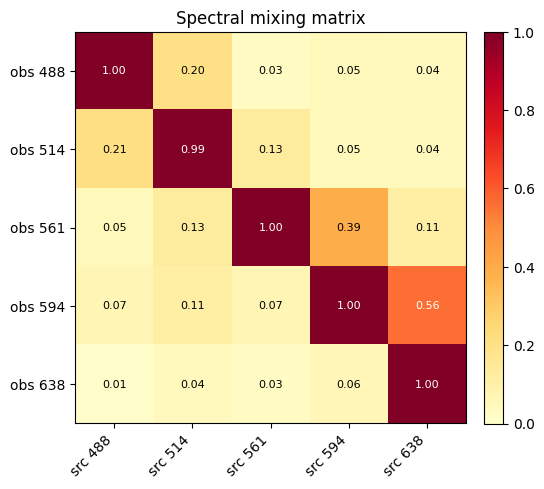

In [13]:
# ── Step 2: visualise the mixing matrix as a heatmap ─────────────────────────

def plot_mixing_matrix(A, channels, title="Spectral mixing matrix"):
    """Heatmap of A.  Diagonal = 1 (self), off-diagonal = bleed-through fractions."""
    fig, ax = plt.subplots(figsize=(len(channels) * 0.9 + 1, len(channels) * 0.9 + 0.5))
    im = ax.imshow(A, vmin=0, vmax=1, cmap="YlOrRd")
    ax.set_xticks(range(len(channels)))
    ax.set_yticks(range(len(channels)))
    ax.set_xticklabels([f"src {c}" for c in channels], rotation=45, ha="right")
    ax.set_yticklabels([f"obs {c}" for c in channels])
    for i in range(len(channels)):
        for j in range(len(channels)):
            ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if A[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    plt.tight_layout()
    return fig

fig_A = plot_mixing_matrix(A_txt, expr_channels_txt)
plt.show()


In [21]:
# ── Step 3: apply unmixing — fast vectorized solve + clip ────────────────────
#
# For a small mixing matrix (C = 4-5 channels), per-voxel scipy.optimize.nnls
# is ~100-1000× slower than a single np.linalg.solve over all voxels.
# Non-negativity is enforced by clipping, which is equivalent to NNLS when
# bleed-through is moderate (the typical HCR case).

def apply_unmixing_fast(channel_crops: dict, A: np.ndarray, channels: list) -> dict:
    """Unmix a single cell crop via vectorized solve + non-negativity clip.

    Parameters
    ----------
    channel_crops : dict[str, np.ndarray]
        Raw channel crops {channel: (Z, Y, X)}.
    A : np.ndarray, shape (C, C)
        Mixing matrix (diagonal = 1, off-diagonals = bleed-through fractions).
    channels : list[str]
        Ordered channel names matching rows/cols of A.

    Returns
    -------
    unmixed : dict[str, np.ndarray]
        {channel: (Z, Y, X)} unmixed volumes.
    """
    shape = channel_crops[channels[0]].shape
    Y = np.stack([channel_crops[c].astype(np.float64).ravel() for c in channels], axis=0)
    # single LAPACK call over all N voxels, then clip negatives
    S = np.maximum(0, np.linalg.solve(A, Y))
    return {c: S[i].reshape(shape).astype(np.float32) for i, c in enumerate(channels)}


unmixed_crops = apply_unmixing_fast(channel_crops, A_txt, expr_channels_txt)
print("Unmixing done. Channels:", list(unmixed_crops.keys()))


Unmixing done. Channels: ['488', '514', '561', '594', '638']


In [ ]:
# ── Batch unmixing: thousands of cells at once ───────────────────────────────
#
# Strategy: A is fixed for the whole round, so concatenate every cell's voxels
# into one (C, N_total) matrix and solve in a single call.
#
#   CPU (numpy):  one np.linalg.solve — best default choice
#   GPU (CuPy):   same but on GPU; ~10-50× faster for large N_total
#                 install with: pip install cupy-cuda12x  (match your CUDA)
#
# Memory: 4 channels × float64 × N_total bytes.
# Rule of thumb: 1 000 cells × 50×50×10 voxels ≈ 25 M voxels → ~800 MB.
# Use batch_size to cap memory if needed.

def apply_unmixing_batch(
    all_channel_crops: list,
    A: np.ndarray,
    channels: list,
    use_gpu: bool = False,
    batch_size: int = None,
) -> list:
    """Unmix many cell crops in one vectorized solve.

    Parameters
    ----------
    all_channel_crops : list[dict[str, np.ndarray]]
        One crops dict per cell, each {channel: (Z, Y, X)}.
    A : np.ndarray, shape (C, C)
        Mixing matrix — same for every cell in the round.
    channels : list[str]
    use_gpu : bool
        Use CuPy for GPU-accelerated solve (requires cupy).
    batch_size : int, optional
        Max cells per solve to cap RAM/VRAM.  None = all at once.

    Returns
    -------
    list[dict[str, np.ndarray]]
        One unmixed crops dict per input cell, same order.
    """
    if batch_size is not None:
        results = []
        for i in range(0, len(all_channel_crops), batch_size):
            results.extend(apply_unmixing_batch(
                all_channel_crops[i:i + batch_size], A, channels, use_gpu=use_gpu
            ))
        return results

    shapes = [crops[channels[0]].shape for crops in all_channel_crops]
    sizes  = [int(np.prod(s)) for s in shapes]

    # (C, N_total) — all cells concatenated
    Y_all = np.concatenate([
        np.stack([crops[c].astype(np.float64).ravel() for c in channels], axis=0)
        for crops in all_channel_crops
    ], axis=1)

    if use_gpu:
        import cupy as cp
        S_all = cp.asnumpy(cp.maximum(0.0, cp.linalg.solve(cp.array(A), cp.array(Y_all))))
    else:
        S_all = np.maximum(0.0, np.linalg.solve(A, Y_all))

    # split back into per-cell dicts
    results, offset = [], 0
    for shape, size in zip(shapes, sizes):
        S = S_all[:, offset:offset + size]
        offset += size
        results.append({c: S[j].reshape(shape).astype(np.float32) for j, c in enumerate(channels)})
    return results


# ── example: process a list of cells ─────────────────────────────────────────
# all_crops = [load_cell_zarr_chunks_all_channels(dataset, "R2", cid)[0] for cid in cids]
# unmixed_list = apply_unmixing_batch(all_crops, A_txt, expr_channels_txt)
#
# GPU (if available):
# unmixed_list = apply_unmixing_batch(all_crops, A_txt, expr_channels_txt, use_gpu=True)
#
# Memory-capped (500 cells at a time):
# unmixed_list = apply_unmixing_batch(all_crops, A_txt, expr_channels_txt, batch_size=500)


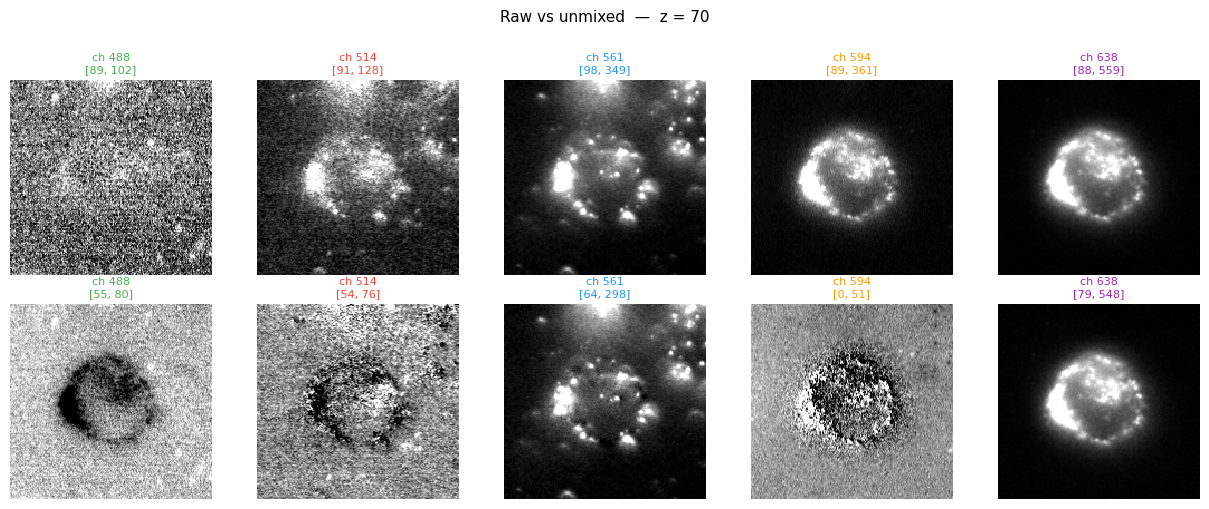

In [ ]:
# ── Step 4: compare raw vs unmixed side-by-side ──────────────────────────────

def plot_raw_vs_unmixed(channel_crops, unmixed_crops, extras, channels,
                        z_plane=None, percentile_range=(2, 98),
                        vmin_vmax="auto",
                        cmap_dict=None, figsize_per_panel=(2.5, 2.5)):
    """Two-row grid: top row = raw, bottom row = unmixed.

    Parameters
    ----------
    vmin_vmax : "auto" | (vmin, vmax) | dict[str, (vmin, vmax)]
        "auto"         — per-channel percentile stretch computed independently
                         for each row (raw / unmixed).
        (vmin, vmax)   — fixed range applied to every channel in both rows.
        dict           — per-channel fixed range, e.g. {"488": (0, 800)}.
                         Channels not in the dict fall back to "auto".
    """
    if cmap_dict is None:
        cmap_dict = Z1_CHANNEL_CMAP_VIBRANT

    if z_plane is None:
        z_planes = extras.get("z_planes")
        z_plane = int(z_planes[len(z_planes) // 2]) if z_planes is not None else \
            channel_crops[channels[0]].shape[0] // 2

    cell_mask_only = extras.get("cell_mask_only")
    C = len(channels)
    fig, axes = plt.subplots(2, C,
                             figsize=(figsize_per_panel[0] * C, figsize_per_panel[1] * 2),
                             squeeze=False)

    for row, (crops, row_label) in enumerate([(channel_crops, "raw"), (unmixed_crops, "unmixed")]):
        for col, chan in enumerate(channels):
            ax = axes[row][col]
            slc = crops[chan][z_plane].astype(np.float32)

            # resolve vmin/vmax
            if isinstance(vmin_vmax, dict):
                rng = vmin_vmax.get(chan, "auto")
            else:
                rng = vmin_vmax

            if rng == "auto":
                vmin, vmax = np.percentile(slc, percentile_range)
            else:
                vmin, vmax = rng

            ax.imshow(slc, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")

            if cell_mask_only is not None:
                outline = cell_mask_only[z_plane].astype(float)
                color = cmap_dict.get(chan, "#ffffff")
                r, g, b, _ = to_rgba(color)
                rgba = np.zeros((*outline.shape, 4))
                rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
                rgba[..., 3] = outline * 0.8
                ax.imshow(rgba, interpolation="nearest")

            title = f"ch {chan}\n[{vmin:.0f}, {vmax:.0f}]"
            ax.set_title(title, color=cmap_dict.get(chan, "white"), fontsize=8)
            ax.axis("off")

        axes[row][0].set_ylabel(row_label, fontsize=10, labelpad=4)

    fig.suptitle(f"Raw vs unmixed  —  z = {z_plane}", fontsize=11, y=1.01)
    plt.tight_layout()
    return fig

fig_cmp = plot_raw_vs_unmixed(channel_crops, unmixed_crops, extras, expr_channels_txt)
plt.show()


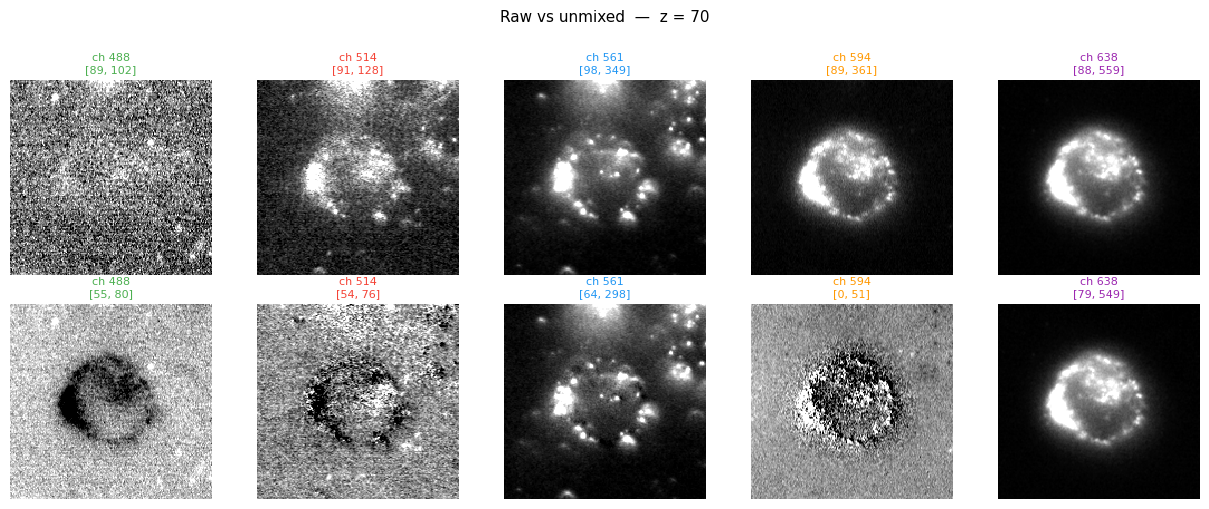

In [22]:

fig_cmp = plot_raw_vs_unmixed(channel_crops, unmixed_crops, extras, expr_channels_txt)
plt.show()

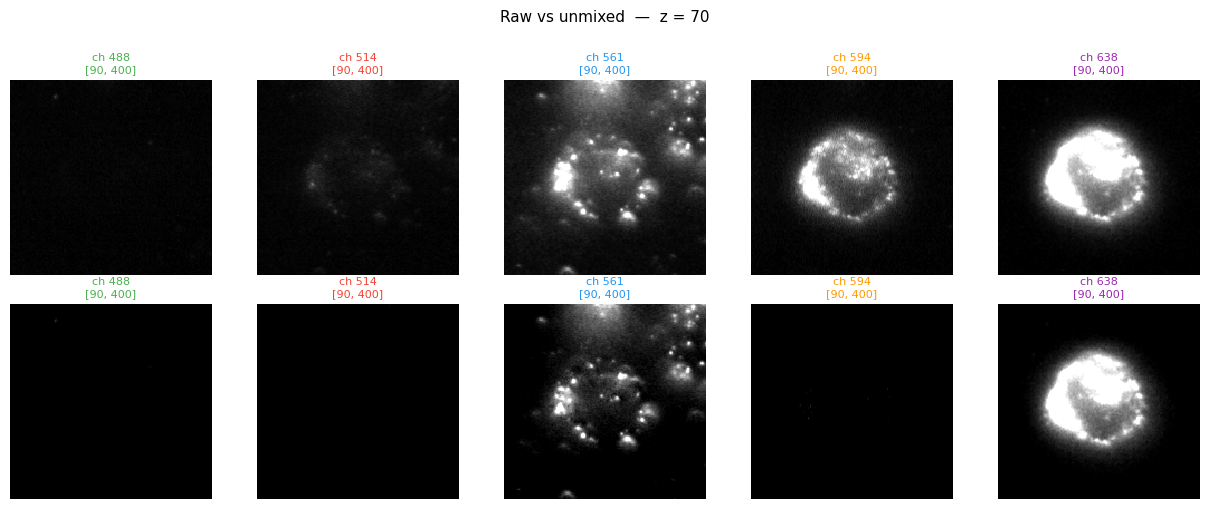

In [20]:
fig_cmp = plot_raw_vs_unmixed(channel_crops, unmixed_crops, extras, expr_channels_txt, vmin_vmax=(90,400))
plt.show()

In [31]:
import matplotlib.animation as animation
from IPython.display import HTML


def make_unmixing_gif(
    channel_crops: dict,
    unmixed_crops: dict,
    extras: dict,
    channels: list,
    vmin_vmax: tuple,
    cell_id: int = None,
    round_key: str = None,
    mouse_id: str = None,
    z_plane: int = None,
    interval: int = 600,
    cmap_dict: dict = None,
    figsize_per_panel: tuple = (2.5, 2.5),
    save_path=None,
) -> animation.FuncAnimation:
    """Animate a flip between raw and unmixed channel images.

    Parameters
    ----------
    channel_crops, unmixed_crops : dict[str, np.ndarray]
        Raw and unmixed channel volumes {channel: (Z, Y, X)}.
    extras : dict
        From load_cell_zarr_chunks_all_channels (used for cell mask overlay).
    channels : list[str]
        Ordered channel names to display.
    vmin_vmax : (vmin, vmax)
        Fixed intensity range applied to all channels in both frames.
        A fixed range is required so the flip is visually meaningful.
    cell_id : int, optional
        Cell ID to annotate in the label panel.
    round_key : str, optional
        Round label (e.g. "R2") to annotate in the label panel.
    mouse_id : str, optional
        Mouse ID to annotate in the label panel.
    z_plane : int, optional
        Z slice to display. Defaults to middle plane.
    interval : int
        Milliseconds per frame — controls flip speed. Default 600 ms.
    cmap_dict : dict, optional
        {channel: hex/color}.  Falls back to Z1_CHANNEL_CMAP_VIBRANT.
    figsize_per_panel : tuple
        (w, h) per channel panel in inches.
    save_path : str or Path, optional
        If provided, saves the animation as a GIF to this path.

    Returns
    -------
    anim : matplotlib.animation.FuncAnimation
        Display inline with: HTML(anim.to_jshtml())
        Save manually with:  anim.save("out.gif", writer="pillow")
    """
    if cmap_dict is None:
        cmap_dict = Z1_CHANNEL_CMAP_VIBRANT

    if z_plane is None:
        z_planes = extras.get("z_planes")
        z_plane = int(z_planes[len(z_planes) // 2]) if z_planes is not None else \
            channel_crops[channels[0]].shape[0] // 2

    cell_mask_only = extras.get("cell_mask_only")
    vmin, vmax = vmin_vmax
    C = len(channels)

    # Layout: narrow label column on the left + one panel per channel
    fig, axes = plt.subplots(
        1, C + 1,
        figsize=((C + 0.6) * figsize_per_panel[0], figsize_per_panel[1]),
        gridspec_kw={"width_ratios": [0.35] + [1] * C},
    )
    fig.patch.set_facecolor("black")

    # ── left label axis ───────────────────────────────────────────────────────
    label_ax = axes[0]
    label_ax.set_facecolor("black")
    label_ax.axis("off")

    # static metadata lines (mouse id, round, cell id, vmin/vmax)
    meta_lines = []
    if mouse_id is not None:
        meta_lines.append(f"Mouse {mouse_id}")
    if round_key is not None:
        meta_lines.append(round_key)
    if cell_id is not None:
        meta_lines.append(f"Cell {cell_id}")
    meta_lines.append(f"[{vmin:.0f}, {vmax:.0f}]")

    label_ax.text(
        0.5, 0.20,
        "\n".join(meta_lines),
        color="#aaaaaa", fontsize=7.5,
        ha="center", va="bottom", transform=label_ax.transAxes,
        linespacing=1.6,
    )

    # animated RAW / UNMIXED label
    label_text = label_ax.text(
        0.5, 0.68, "RAW",
        color="white", fontsize=12, fontweight="bold",
        ha="center", va="center", transform=label_ax.transAxes,
    )

    # ── image axes ────────────────────────────────────────────────────────────
    img_axes = axes[1:]
    im_list = []

    for col, chan in enumerate(channels):
        ax = img_axes[col]
        ax.set_facecolor("black")
        slc = channel_crops[chan][z_plane].astype(np.float32)
        im = ax.imshow(slc, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
        im_list.append(im)

        if cell_mask_only is not None:
            outline = cell_mask_only[z_plane].astype(float)
            color = cmap_dict.get(chan, "#ffffff")
            r, g, b, _ = to_rgba(color)
            rgba = np.zeros((*outline.shape, 4))
            rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
            rgba[..., 3] = outline * 0.6
            ax.imshow(rgba, interpolation="nearest")

        ax.set_title(f"ch {chan}", color=cmap_dict.get(chan, "white"), fontsize=8)

        # light gray outline around each panel
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("#aaaaaa")
            spine.set_linewidth(1.0)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()

    frames_data = [(channel_crops, "RAW"), (unmixed_crops, "UNMIXED")]

    def update(frame_idx):
        crops, label = frames_data[frame_idx]
        label_text.set_text(label)
        for col, chan in enumerate(channels):
            im_list[col].set_data(crops[chan][z_plane].astype(np.float32))

    anim = animation.FuncAnimation(
        fig, update,
        frames=len(frames_data),
        interval=interval,
        repeat=True,
    )

    if save_path is not None:
        fps = max(1, round(1000 / interval))
        anim.save(save_path, writer="pillow", fps=fps)
        print(f"Saved GIF → {save_path}")

    plt.close(fig)
    return anim


cid = 32882
# ── example ───────────────────────────────────────────────────────────────────
anim = make_unmixing_gif(
    channel_crops, unmixed_crops, extras, expr_channels_txt,
    vmin_vmax=(90, 400),
    cell_id=cid,
    round_key=ROUND_KEY,
    mouse_id=MOUSE_ID,
    interval=900,           # ms per frame — lower = faster flip
    save_path=OUTPUT_DIR / f"cell{cid}_unmixing.gif"
)
HTML(anim.to_jshtml())


Saved GIF → /root/capsule/scratch/single_cell_unmixing/782149/cell32882_unmixing.gif
